### Step 1: Download the IEEE 118-Bus System

methodology citation: Donti, P., Amos, B., & Kolter, J. Z. (2017). Task-based End-to-End Model Learning in Stochastic Optimization. Advances in Neural Information Processing Systems (NeurIPS), 30. (This paper is foundational for bridging neural network load predictions directly with downstream non-linear grid optimization).

In [18]:
import urllib.request
import pandas as pd
import re

# 1. Download the file
url = "https://raw.githubusercontent.com/power-grid-lib/pglib-opf/master/pglib_opf_case118_ieee.m"
filename = "pglib_opf_case118_ieee.m"
print("Downloading IEEE 118-bus case...")
urllib.request.urlretrieve(url, filename)

def parse_matpower_matrix(filepath, matrix_name):
    with open(filepath, 'r') as f:
        content = f.read()
    
    # Use regex to find the block of text between 'mpc.matrix_name = [' and '];'
    pattern = rf"mpc\.{matrix_name}\s*=\s*\[(.*?)\];"
    match = re.search(pattern, content, re.DOTALL)
        
    data = []
    # Read line by line, ignoring MATLAB comments (%)
    for line in match.group(1).strip().split('\n'):
        # Strip comments, remove MATLAB semicolons, and clean whitespace
        clean_line = line.split('%')[0].replace(';', '').strip()
            
        row = [float(x) for x in clean_line.split()]
        data.append(row)
        
    return pd.DataFrame(data)

# =====================================================================
# 3. EXTRACT THE DC-OPF DATA
# =====================================================================

# --- BUS DATA ---
# Col 0: Bus ID | Col 2: Active Demand (Pd) in MW
bus_df = parse_matpower_matrix(filename, 'bus')
nodal_demand = bus_df[[0, 2]].rename(columns={0: 'bus_id', 2: 'Pd_mw'})

# --- GENERATOR DATA (WITH FIXED ALPHAS) ---
# Col 0: Bus ID | Col 1: Base Pg | Col 8: Pmax (MW) | Col 9: Pmin (MW)
gen_df = parse_matpower_matrix(filename, 'gen')
gen_limits = gen_df[[0, 1, 8, 9]].rename(columns={
    0: 'bus_id', 
    1: 'Pg_base_mw', 
    8: 'Pmax_mw', 
    9: 'Pmin_mw'
})

# 1. Calculate available headroom for each generator
gen_limits['headroom_mw'] = gen_limits['Pmax_mw'] - gen_limits['Pg_base_mw']

# 2. Safety clip: Ensure no negative headroom (in case of MATPOWER rounding quirks)
gen_limits['headroom_mw'] = gen_limits['headroom_mw'].clip(lower=0.0)

# 3. Calculate the fixed alpha (Participation Factor)
total_headroom = gen_limits['headroom_mw'].sum()

if total_headroom > 0:
    gen_limits['alpha_fixed'] = gen_limits['headroom_mw'] / total_headroom
else:
    # Fallback if no headroom exists system-wide (unlikely in standard cases)
    gen_limits['alpha_fixed'] = 1.0 / len(gen_limits)

print("Fixed Alpha values calculated successfully. Top 5 contributors:")
print(gen_limits[['bus_id', 'Pg_base_mw', 'Pmax_mw', 'alpha_fixed']].sort_values('alpha_fixed', ascending=False).head())

# --- BRANCH DATA ---
# Col 0: From Bus | Col 1: To Bus | Col 3: Reactance (x) | Col 5: Rate A (MW limit)
branch_df = parse_matpower_matrix(filename, 'branch')
branch_data = branch_df[[0, 1, 3, 5]].rename(columns={0: 'from_bus', 1: 'to_bus', 3: 'x_reactance', 5: 'thermal_limit_mw'})

# Calculate Susceptance (B = 1/x) for your DC-OPF B-matrix
branch_data['B_susceptance'] = 1.0 / branch_data['x_reactance']

# --- GENERATOR COSTS ---
# Col 3: Number of coefficients | Col 5: Linear cost (c1) | Col 6: Constant cost (c0)
# Note: PGLib 118 uses linear costs, so n=2 (represented by 2 coefficients)
gencost_df = parse_matpower_matrix(filename, 'gencost')
gen_costs = gencost_df[[5, 6]].rename(columns={5: 'cost_linear', 6: 'cost_constant'})

print("Extraction Successful! Here is a sample of your branch data:")
print(branch_data.head())

Fixed Alpha values calculated successfully. Top 5 contributors:
    bus_id  Pg_base_mw  Pmax_mw  alpha_fixed
29    69.0       591.0   1182.0     0.181427
28    66.0       392.0    784.0     0.120338
44   100.0       326.5    653.0     0.100230
39    89.0       318.5    637.0     0.097774
36    80.0       254.5    509.0     0.078127
Extraction Successful! Here is a sample of your branch data:
   from_bus  to_bus  x_reactance  thermal_limit_mw  B_susceptance
0       1.0     2.0      0.09990             151.0      10.010010
1       1.0     3.0      0.04240             151.0      23.584906
2       4.0     5.0      0.00798             176.0     125.313283
3       3.0     5.0      0.10800             175.0       9.259259
4       5.0     6.0      0.05400             176.0      18.518519


### 2. Download Demand Data

citation: A novel probabilistic gradient boosting model withmulti-approachfeature selection and iterative seasonal trend decomposition for short-term load forecasting
Priyesh Saini∗, S.K. Parida

In [3]:
import pandas as pd
import numpy as np
import requests
import io
import time
from gridstatus import CAISO

START = "2022-02-03"
END   = "2023-02-03"

# --- 1. CAISO 5-minute system demand ---
iso = CAISO()
load = iso.get_load(
    start=pd.Timestamp(START, tz="US/Pacific"),
    end=pd.Timestamp(END,   tz="US/Pacific"),
)

load = load.rename(columns={"Load": "load_mw", "Time": "timestamp"})
load["timestamp"] = (pd.to_datetime(load["timestamp"])
                      .dt.tz_convert("US/Pacific")
                      .dt.tz_localize(None))
load["timestamp"] = load["timestamp"].dt.round("5min")
load = (load[["timestamp", "load_mw"]]
        .drop_duplicates("timestamp")
        .sort_values("timestamp")
        .set_index("timestamp"))

# =====================================================================
# 2. ROBUST LAX ASOS: Chunked 5-minute temperature + RH
# =====================================================================
def fetch_asos_chunk(start_dt, end_dt, retries=5): # Increased retries just in case
    """Fetches a small time chunk from IEM with automatic exponential backoff."""
    url = (
        "https://mesonet.agron.iastate.edu/cgi-bin/request/asos.py"
        f"?station=LAX&data=tmpf,relh"
        f"&year1={start_dt.year}&month1={start_dt.month}&day1={start_dt.day}"
        f"&year2={end_dt.year}&month2={end_dt.month}&day2={end_dt.day}"
        "&tz=America/Los_Angeles&format=onlycomma&latlon=no&missing=empty"
    )
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
    
    for attempt in range(retries):
        response = requests.get(url, headers=headers)
        if response.status_code == 200:
            return pd.read_csv(io.StringIO(response.text), parse_dates=["valid"])
            
        # Catch BOTH 503 (Server Busy) and 429 (Too Many Requests)
        elif response.status_code in [503, 429]:
            wait_time = 2 ** (attempt + 1) + 2  # Added a small buffer
            print(f"  [!] HTTP {response.status_code}. Retrying in {wait_time}s...")
            time.sleep(wait_time)
        else:
            response.raise_for_status()
            
    raise Exception(f"Failed to fetch {start_dt.date()} after {retries} retries.")

print("Fetching weather data in 30-day chunks to prevent IEM server timeouts...")

# Create 30-day intervals to loop through
date_chunks = pd.date_range(start=START, end=END, freq='30D').tolist()
if pd.Timestamp(END) not in date_chunks:
    date_chunks.append(pd.Timestamp(END))

wx_chunks = []
for i in range(len(date_chunks) - 1):
    s = date_chunks[i]
    e = date_chunks[i+1]
    print(f"  -> Pulling chunk: {s.date()} to {e.date()}")
    
    chunk_df = fetch_asos_chunk(s, e)
    wx_chunks.append(chunk_df)
    time.sleep(3)  # Polite pause between chunks

# Combine all the chunks into one DataFrame
wx = pd.concat(wx_chunks, ignore_index=True)
wx = wx.drop_duplicates(subset=["valid"])

# Continue with your exact original data processing
wx = wx.rename(columns={"valid": "timestamp", "tmpf": "temp_f", "relh": "rh_pct"})
wx["temperature"] = (wx["temp_f"] - 32) * 5/9            

T  = wx["temperature"]
RH = wx["rh_pct"]
wx["humidity"] = (6.112 * np.exp(17.67 * T / (T + 243.5)) * RH * 2.1674) / (273.15 + T)

wx = wx[["timestamp", "temperature", "humidity"]].dropna()
wx["timestamp"] = wx["timestamp"].dt.round("5min")
wx = (wx.groupby("timestamp").mean().sort_index())

grid = pd.date_range(load.index.min(), load.index.max(), freq="5min")
wx = wx.reindex(grid).interpolate("time", limit=12)   

# --- 3. Merge + sanity check ---
df = load.join(wx, how="inner")
print(f"\nLoad rows:    {len(load):,}")
print(f"Weather rows: {len(wx.dropna()):,}")
print(f"Merged rows:  {len(df):,}   (expect ~105,000 for one year of 5-min)")

100%|██████████| 365/365 [02:12<00:00,  2.76it/s]


Fetching weather data in 30-day chunks to prevent IEM server timeouts...
  -> Pulling chunk: 2022-02-03 to 2022-03-05
  -> Pulling chunk: 2022-03-05 to 2022-04-04
  [!] HTTP 429. Retrying in 4s...
  [!] HTTP 429. Retrying in 6s...
  [!] HTTP 429. Retrying in 10s...
  [!] HTTP 429. Retrying in 18s...
  -> Pulling chunk: 2022-04-04 to 2022-05-04
  [!] HTTP 429. Retrying in 4s...
  [!] HTTP 429. Retrying in 6s...
  [!] HTTP 429. Retrying in 10s...
  [!] HTTP 429. Retrying in 18s...
  -> Pulling chunk: 2022-05-04 to 2022-06-03
  [!] HTTP 429. Retrying in 4s...
  [!] HTTP 429. Retrying in 6s...
  [!] HTTP 429. Retrying in 10s...
  [!] HTTP 429. Retrying in 18s...
  -> Pulling chunk: 2022-06-03 to 2022-07-03
  [!] HTTP 429. Retrying in 4s...
  [!] HTTP 429. Retrying in 6s...
  [!] HTTP 429. Retrying in 10s...
  [!] HTTP 429. Retrying in 18s...
  -> Pulling chunk: 2022-07-03 to 2022-08-02
  [!] HTTP 429. Retrying in 4s...
  [!] HTTP 429. Retrying in 6s...
  [!] HTTP 429. Retrying in 10s...
  

### 3. Data Aggregation and Scaling

In [4]:
avg_nodal_demand_base = np.average(nodal_demand)

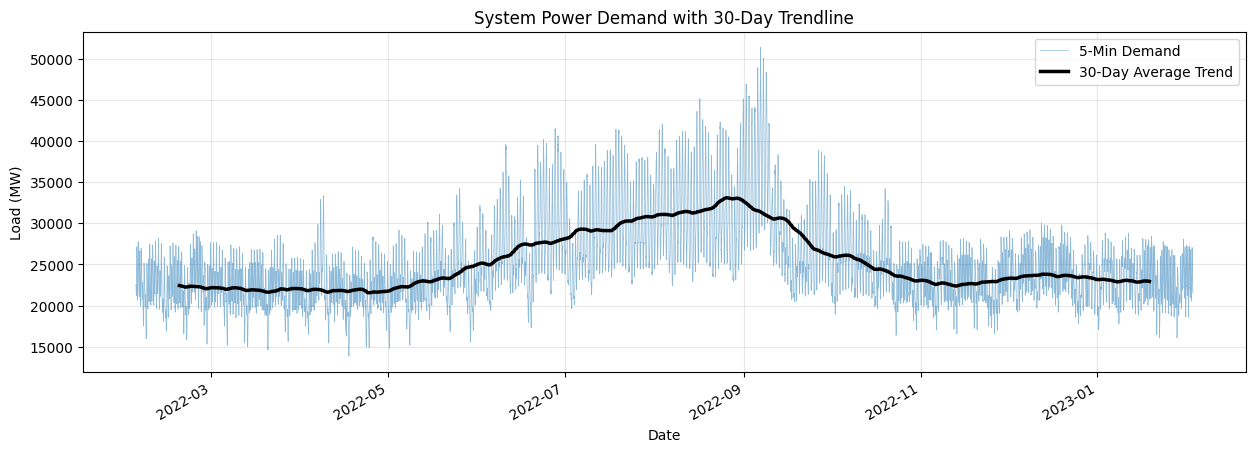

In [5]:
import matplotlib.pyplot as plt

# 1. Calculate the 30-day rolling average
# 30 days = 30 * 288 (5-min intervals per day) = 8640
rolling_30d = df['load_mw'].rolling(window=8640, center=True).mean()

# 2. Plotting
plt.figure(figsize=(15, 5))

# Plot the raw 5-minute demand (made slightly transparent to let the trendline pop)
df['load_mw'].plot(
    color='#1f77b4', 
    linewidth=0.5, 
    alpha=0.5, 
    label='5-Min Demand'
)

# Plot the 30-Day Rolling Average Trendline
rolling_30d.plot(
    color='black',       # Strong contrasting color 
    linewidth=2.5,       # Thicker line to stand out over the blue density
    label='30-Day Average Trend'
)

# Format the chart
plt.title('System Power Demand with 30-Day Trendline')
plt.ylabel('Load (MW)')
plt.xlabel('Date')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right') # Adds a key to identify the lines

plt.show()

In [6]:
## Scaling factor generation 
df = df.dropna()
median_load = np.median(df['load_mw'])
scaling_factor = df['load_mw'] / median_load
df['scaling_factor'] = scaling_factor

In [7]:
## Identify Generatoy limits (system wide)
system_max = gen_limits['Pmax_mw'].sum()

safety_thresh = 0.95
max_scaling_factor = safety_thresh * system_max / nodal_demand['Pd_mw'].sum()
current_peak = df['scaling_factor'].max()

if current_peak > max_scaling_factor:
    rescale_factor = max_scaling_factor / current_peak
    df['scaling_factor'] = df['scaling_factor'] * rescale_factor

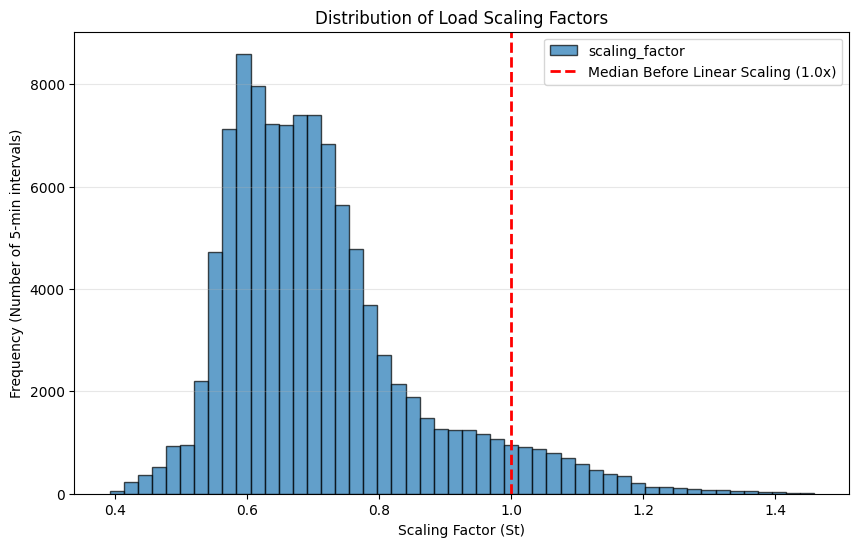

In [8]:
### Plot scaling factors as this is
data = df['scaling_factor']
plt.figure(figsize=(10, 6))

# Plot the histogram with 50 bins for a clean resolution
df['scaling_factor'].plot.hist(
    bins=50, 
    color='#1f77b4',      # Standard blue
    edgecolor='black',    # Adds borders to the bars so they don't blur together
    alpha=0.7             # Slight transparency
)

# Add a red dashed line exactly at the mean (1.0)
plt.axvline(x=1.0, color='red', linestyle='--', linewidth=2, label='Median Before Linear Scaling (1.0x)')

# Format the chart
plt.title('Distribution of Load Scaling Factors')
plt.xlabel('Scaling Factor (St)')
plt.ylabel('Frequency (Number of 5-min intervals)')
plt.grid(True, alpha=0.3, axis='y') # Only grid the y-axis for cleaner look
plt.legend()

plt.show()

In [9]:
## Scale IEEE 118 test bus today to follow the variance of our data

scaled_nodal_demand = pd.DataFrame(
    np.outer(df['scaling_factor'], nodal_demand['Pd_mw']),
    index=df.index,                 # Your 105,000 timestamps become the rows
    columns=nodal_demand['bus_id']  # Your 118 bus IDs become the columns
)


### 4. Demand Distribution and Sample for Scenarios (Dumb Method)

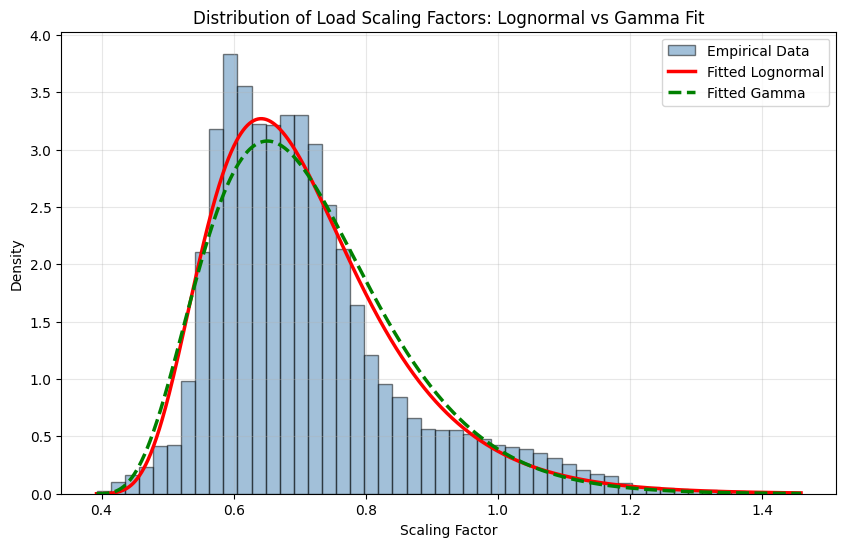

In [10]:
### Fit a distribution to the scaling factors
import scipy.stats as stats

# Assuming 'df' is your DataFrame and 'scaling_factor' is the column
# Drop any NaN values before fitting
data = df['scaling_factor'].dropna().values

shape_lognorm, loc_lognorm, scale_lognorm = stats.lognorm.fit(data)
shape_gamma, loc_gamma, scale_gamma = stats.gamma.fit(data)

x = np.linspace(data.min(), data.max(), 1000)
pdf_lognorm = stats.lognorm.pdf(x, shape_lognorm, loc_lognorm, scale_lognorm)
pdf_gamma = stats.gamma.pdf(x, shape_gamma, loc_gamma, scale_gamma)

# --- 4. Plot the Results ---
plt.figure(figsize=(10, 6))

# Plot the empirical histogram (must set density=True to match PDF scale)
plt.hist(data, bins=50, density=True, alpha=0.5, color='steelblue', edgecolor='black', label='Empirical Data')

# Overlay the fitted PDFs
plt.plot(x, pdf_lognorm, 'r-', lw=2.5, label='Fitted Lognormal')
plt.plot(x, pdf_gamma, 'g--', lw=2.5, label='Fitted Gamma')

plt.title('Distribution of Load Scaling Factors: Lognormal vs Gamma Fit')
plt.xlabel('Scaling Factor')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [11]:
# Calculate the negative log-likelihood (NLL) for both fits
# NLL is what scipy actually minimizes during the fit
nll_lognorm = stats.lognorm.nnlf((shape_lognorm, loc_lognorm, scale_lognorm), data)
nll_gamma = stats.gamma.nnlf((shape_gamma, loc_gamma, scale_gamma), data)

# Number of parameters (k) is 3 for both distributions (shape, loc, scale)
k = 3
n = len(data)

# Calculate AIC: AIC = 2k - 2*ln(L)  (where -ln(L) is the NLL)
aic_lognorm = 2 * k + 2 * nll_lognorm
aic_gamma = 2 * k + 2 * nll_gamma

print(f"Lognormal AIC: {aic_lognorm:.2f}")
print(f"Gamma AIC: {aic_gamma:.2f}")

if aic_lognorm < aic_gamma:
    print("The Lognormal distribution provides a better fit.")
else:
    print("The Gamma distribution provides a better fit.")

Lognormal AIC: -129519.73
Gamma AIC: -126916.73
The Lognormal distribution provides a better fit.


In [12]:
### Generate the scenarios
num_samples = 100
scale_scenarios = stats.lognorm.rvs(shape_lognorm, loc=loc_lognorm, scale=scale_lognorm, size=num_samples)
nodes_to_mult = nodal_demand['Pd_mw']
node_scenarios = np.outer(scale_scenarios, nodes_to_mult)

In [ ]:
from scipy.stats import lognorm
scaling_factor_hat = lognorm.mean(shape_lognorm, loc=loc_lognorm, scale=scale_lognorm)
Pn_d_hat = scaling_factor_hat * nodal_demand.set_index('bus_id')['Pd_mw']

### 5. Run Two Stage Optimization (First Methodology)

Prdict Demand, input into first stage, optimize, then use scenarios and optimize second stage, cost is sum. 

In [25]:
# =============================================================================
# Two-Stage Stochastic DC-OPF — Formulation 1 (pyomo version)
# Stage 1: deterministic DC-OPF on point forecast Pn_d_hat -> Pg_star
# Stage 2: per-scenario recourse with load-shed / curtailment slacks
# =============================================================================
import numpy as np
import pandas as pd
import pyomo.environ as pyo
from pyomo.opt import SolverFactory

# -----------------------------------------------------------------------------
# 1. Build index maps and system data
# -----------------------------------------------------------------------------
bus_ids   = nodal_demand['bus_id'].astype(int).values
N_BUS     = len(bus_ids)
bus_idx   = {int(b): i for i, b in enumerate(bus_ids)}

gen_bus     = gen_limits['bus_id'].astype(int).values
gen_bus_idx = np.array([bus_idx[int(b)] for b in gen_bus])
Pg_min      = gen_limits['Pmin_mw'].values
Pg_max      = gen_limits['Pmax_mw'].values
c1          = gen_costs['cost_linear'].values
c0          = gen_costs['cost_constant'].values
N_GEN       = len(gen_bus)

from_idx = np.array([bus_idx[int(b)] for b in branch_data['from_bus']])
to_idx   = np.array([bus_idx[int(b)] for b in branch_data['to_bus']])
B_line   = branch_data['B_susceptance'].values
R_line   = branch_data['thermal_limit_mw'].values
N_LINE   = len(B_line)

SLACK  = 0
VOLL   = 10000.0
C_CURT = 1000.0

RAMP_UP_COST   = 50.0   # $/MWh, uniform across generators
RAMP_DOWN_COST = 10.0   # $/MWh, uniform

c_up   = np.full(N_GEN, RAMP_UP_COST)
c_down = np.full(N_GEN, RAMP_DOWN_COST)


# Align Pn_d_hat to bus order
if isinstance(Pn_d_hat, pd.Series):
    Pd_hat = np.array([Pn_d_hat[b] for b in bus_ids])
else:
    Pd_hat = np.asarray(Pn_d_hat)


In [26]:

# # -----------------------------------------------------------------------------
# # 2. Helper: build a DC-OPF pyomo model (reused for stage 1 and stage 2)
# # -----------------------------------------------------------------------------
# def build_dcopf(Pd, Pg_fixed=None, recourse_mode=False):
#     """
#     Build a DC-OPF model.
#     - Stage 1:  Pg_fixed=None, recourse_mode=False  -> dispatch Pg freely.
#     - Stage 2:  Pg_fixed=Pg_star, recourse_mode=True -> dispatch = Pg_star + dP_up - dP_dn,
#                 with load-shed/curtailment slacks at high penalty.
#     """
#     m = pyo.ConcreteModel()

#     m.G = pyo.RangeSet(0, N_GEN - 1)
#     m.N = pyo.RangeSet(0, N_BUS - 1)
#     m.E = pyo.RangeSet(0, N_LINE - 1)

#     m.theta = pyo.Var(m.N, domain=pyo.Reals, initialize=0.0)
#     m.Pe    = pyo.Var(m.E, domain=pyo.Reals, bounds=lambda m, e: (-R_line[e], R_line[e]))

#     if not recourse_mode:
#         # Stage 1: dispatch Pg within bounds
#         m.Pg = pyo.Var(m.G, domain=pyo.Reals, bounds=lambda m, g: (Pg_min[g], Pg_max[g]))
#     else:
#         # Stage 2: Pg = Pg_fixed + dP_up - dP_dn
#         m.dP_up = pyo.Var(m.G, domain=pyo.NonNegativeReals)
#         m.dP_dn = pyo.Var(m.G, domain=pyo.NonNegativeReals)
#         m.G_shed = pyo.Var(m.N, domain=pyo.NonNegativeReals, bounds=lambda m, n: (0, Pd[n]))
#         m.G_curt = pyo.Var(m.N, domain=pyo.NonNegativeReals)

#         # Derived Pg expression
#         def _Pg_expr(m, g):
#             return Pg_fixed[g] + m.dP_up[g] - m.dP_dn[g]
#         m.Pg = pyo.Expression(m.G, rule=_Pg_expr)

#         # Enforce physical generator limits on the actual dispatch
#         m.pg_lo = pyo.Constraint(m.G, rule=lambda m, g: m.Pg[g] >= Pg_min[g])
#         m.pg_hi = pyo.Constraint(m.G, rule=lambda m, g: m.Pg[g] <= Pg_max[g])

#     # Slack bus angle
#     m.slack_con = pyo.Constraint(expr=m.theta[SLACK] == 0)

#     # DC flow equation: Pe = B * (theta_from - theta_to)
#     def _flow_rule(m, e):
#         return m.Pe[e] == B_line[e] * (m.theta[from_idx[e]] - m.theta[to_idx[e]])
#     m.flow = pyo.Constraint(m.E, rule=_flow_rule)

#     # Power balance at each bus
#     # gen_at_bus - demand = net outflow on lines
#     # Precompute which generators and lines touch each bus
#     gens_at_bus    = {n: [g for g in range(N_GEN) if gen_bus_idx[g] == n] for n in range(N_BUS)}
#     lines_from_bus = {n: [e for e in range(N_LINE) if from_idx[e] == n] for n in range(N_BUS)}
#     lines_to_bus   = {n: [e for e in range(N_LINE) if to_idx[e]   == n] for n in range(N_BUS)}

#     def _balance_rule(m, n):
#         gen_inj  = sum(m.Pg[g] for g in gens_at_bus[n])
#         out_flow = sum(m.Pe[e] for e in lines_from_bus[n])
#         in_flow  = sum(m.Pe[e] for e in lines_to_bus[n])
#         net_outflow = out_flow - in_flow
#         if recourse_mode:
#             # Effective demand is Pd - G_shed; excess generation absorbed by G_curt
#             return gen_inj - (Pd[n] - m.G_shed[n]) - m.G_curt[n] == net_outflow
#         else:
#             return gen_inj - Pd[n] == net_outflow
#     m.balance = pyo.Constraint(m.N, rule=_balance_rule)

#     # Objective
#     if not recourse_mode:
#         m.obj = pyo.Objective(
#             expr=sum(c1[g] * m.Pg[g] for g in range(N_GEN)) + float(np.sum(c0)),
#             sense=pyo.minimize,
#         )
#     else:
#         m.obj = pyo.Objective(
#         expr=(
#             sum(c_up[g] * m.dP_up[g] + c_down[g] * m.dP_dn[g] for g in range(N_GEN))
#             + VOLL   * sum(m.G_shed[n] for n in range(N_BUS))
#             + C_CURT * sum(m.G_curt[n] for n in range(N_BUS))
#         ),
#         sense=pyo.minimize,
#     )
#     return m

# # -----------------------------------------------------------------------------
# # 3. STAGE 1: solve deterministic DC-OPF on forecast
# # -----------------------------------------------------------------------------
# solver = SolverFactory("appsi_highs")   # HiGHS via highspy
# m1 = build_dcopf(Pd_hat, recourse_mode=False)
# res1 = solver.solve(m1)
# assert (res1.solver.termination_condition.name == "optimal"), \
#     f"Stage 1 not optimal: {res1.solver.termination_condition}"

# Pg_star = np.array([pyo.value(m1.Pg[g]) for g in range(N_GEN)])
# cost_s1 = pyo.value(m1.obj)
# print(f"Stage 1 cost: ${cost_s1:,.2f}/hr   (sum Pg={Pg_star.sum():.1f} MW, "
#       f"sum Pd_hat={Pd_hat.sum():.1f} MW)")

# # -----------------------------------------------------------------------------
# # 4. STAGE 2: solve per-scenario recourse
# # -----------------------------------------------------------------------------
# node_scen = np.asarray(node_scenarios)
# N_SCEN    = node_scen.shape[0]

# stage2_costs = np.zeros(N_SCEN)
# shed_mwh     = np.zeros(N_SCEN)
# curt_mwh     = np.zeros(N_SCEN)
# dP_up_mwh    = np.zeros(N_SCEN)
# dP_dn_mwh    = np.zeros(N_SCEN)
# infeasible   = []

# for s in range(N_SCEN):
#     m2 = build_dcopf(node_scen[s, :], Pg_fixed=Pg_star, recourse_mode=True)
#     res2 = solver.solve(m2)
#     if res2.solver.termination_condition.name != "optimal":
#         infeasible.append(s)
#         stage2_costs[s] = np.nan
#         continue
#     stage2_costs[s] = pyo.value(m2.obj)
#     shed_mwh[s]     = sum(pyo.value(m2.G_shed[n]) for n in range(N_BUS))
#     curt_mwh[s]     = sum(pyo.value(m2.G_curt[n]) for n in range(N_BUS))
#     dP_up_mwh[s]    = sum(pyo.value(m2.dP_up[g]) for g in range(N_GEN))
#     dP_dn_mwh[s]    = sum(pyo.value(m2.dP_dn[g]) for g in range(N_GEN))

# # -----------------------------------------------------------------------------
# # 5. Report
# # -----------------------------------------------------------------------------
# valid = ~np.isnan(stage2_costs)
# exp_stage2 = float(np.mean(stage2_costs[valid]))
# total_cost = cost_s1 + exp_stage2

# print("\n" + "="*60)
# print("Two-Stage Stochastic DC-OPF — Formulation 1 Results")
# print("="*60)
# print(f"Stage 1 cost  (deterministic on forecast):  ${cost_s1:>14,.2f}/hr")
# print(f"E[Stage 2 cost] (avg across scenarios):     ${exp_stage2:>14,.2f}/hr")
# print(f"TOTAL expected cost:                        ${total_cost:>14,.2f}/hr")
# print(f"Scenarios solved:  {int(valid.sum())}/{N_SCEN}  (infeasible: {len(infeasible)})")
# print(f"Avg load shed:     {shed_mwh[valid].mean():>8,.2f} MW   "
#       f"(max: {shed_mwh[valid].max():.2f})")
# print(f"Avg curtailment:   {curt_mwh[valid].mean():>8,.2f} MW   "
#       f"(max: {curt_mwh[valid].max():.2f})")
# print(f"Avg up-ramp:       {dP_up_mwh[valid].mean():>8,.2f} MW")
# print(f"Avg down-ramp:     {dP_dn_mwh[valid].mean():>8,.2f} MW")

# results_formulation1 = {
#     "Pg_star":      Pg_star,
#     "cost_s1":      cost_s1,
#     "stage2_costs": stage2_costs,
#     "exp_stage2":   exp_stage2,
#     "total_cost":   total_cost,
#     "shed_mwh":     shed_mwh,
#     "curt_mwh":     curt_mwh,
#     "dP_up_mwh":    dP_up_mwh,
#     "dP_dn_mwh":    dP_dn_mwh,
#     "infeasible":   infeasible,
# }

### 6. Run Two Stage Optimization (Second Methodology)

Predict demand, use this to create scenarios, and then optimize with recourse decision. 

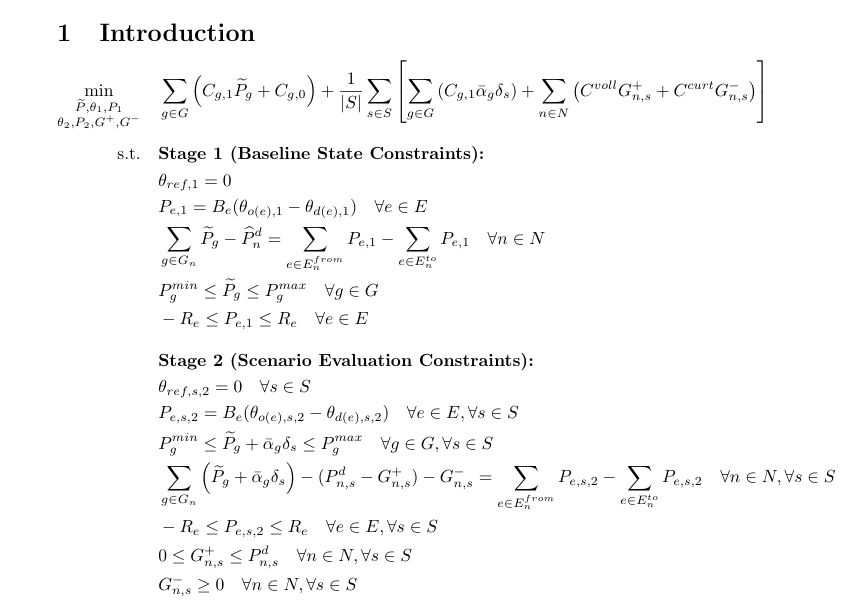

In [24]:
# =============================================================================
# Two-Stage Stochastic DC-OPF — Formulation 2 with AFFINE RECOURSE (Gurobi)
# =============================================================================
# Stage 1: choose (Pg, alpha) knowing the scenario distribution.
# Stage 2: automatic affine response Pg_s = Pg + alpha * delta_s.
# Delta_s is precomputed from raw demand shifts (exact in lossless DC-OPF).
# =============================================================================
import numpy as np
import gurobipy as gp
from gurobipy import GRB

def build_and_solve_affine(Pd_hat, node_scen, voll=VOLL, c_curt=C_CURT, verbose=True):
    N_SCEN = node_scen.shape[0]

    # Precomputed scenario-wide imbalance
    delta = node_scen.sum(axis=1) - Pd_hat.sum()   # shape (N_SCEN,)

    # Incidence lookups
    gens_at_bus    = [[g for g in range(N_GEN) if gen_bus_idx[g] == n] for n in range(N_BUS)]
    lines_from_bus = [[e for e in range(N_LINE) if from_idx[e] == n] for n in range(N_BUS)]
    lines_to_bus   = [[e for e in range(N_LINE) if to_idx[e]   == n] for n in range(N_BUS)]

    # --- Model ---
    m = gp.Model("stochastic_dcopf_affine")
    m.Params.OutputFlag = 1 if verbose else 0

    # --- Stage 1 variables ---
    Pg     = m.addMVar(N_GEN, lb=Pg_min, ub=Pg_max, name="Pg")
    theta1 = m.addMVar(N_BUS, lb=-GRB.INFINITY, name="theta1")
    Pe1    = m.addMVar(N_LINE, lb=-R_line, ub=R_line, name="Pe1")

    # --- Stage 2 variables (per scenario) ---
    G_shed = m.addMVar((N_SCEN, N_BUS), lb=0.0, ub=node_scen, name="G_shed")
    G_curt = m.addMVar((N_SCEN, N_BUS), lb=0.0, name="G_curt")
    theta2 = m.addMVar((N_SCEN, N_BUS), lb=-GRB.INFINITY, name="theta2")
    Pe2    = m.addMVar((N_SCEN, N_LINE),
                       lb=np.tile(-R_line, (N_SCEN, 1)),
                       ub=np.tile( R_line, (N_SCEN, 1)), name="Pe2")

    # --- Stage 1 constraints ---
    m.addConstr(theta1[SLACK] == 0, name="slack1")

    for e in range(N_LINE):
        m.addConstr(Pe1[e] == B_line[e] * (theta1[from_idx[e]] - theta1[to_idx[e]]),
                    name=f"flow1_{e}")

    for n in range(N_BUS):
        gen_sum = gp.quicksum(Pg[g] for g in gens_at_bus[n])
        out_sum = gp.quicksum(Pe1[e] for e in lines_from_bus[n])
        in_sum  = gp.quicksum(Pe1[e] for e in lines_to_bus[n])
        m.addConstr(gen_sum - Pd_hat[n] == out_sum - in_sum, name=f"balance1_{n}")

# --- Stage 2 constraints ---
    
    # Convert the dataframe column to a fixed numpy array
    alpha_fixed = gen_limits['alpha_fixed'].values

    for s in range(N_SCEN):
        m.addConstr(theta2[s, SLACK] == 0, name=f"slack2_{s}")

        for e in range(N_LINE):
            m.addConstr(
                Pe2[s, e] == B_line[e] * (theta2[s, from_idx[e]] - theta2[s, to_idx[e]]),
                name=f"flow2_{s}_{e}",
            )

        # Pg_s = Pg + alpha_fixed * delta_s  (linear since delta_s is a constant)
        for g in range(N_GEN):
            Pg_s = Pg[g] + alpha_fixed[g] * delta[s]
            m.addConstr(Pg_s >= Pg_min[g], name=f"pg_lo_{s}_{g}")
            m.addConstr(Pg_s <= Pg_max[g], name=f"pg_hi_{s}_{g}")

        for n in range(N_BUS):
            # Replace alpha[g] with alpha_fixed[g] here
            gen_inj = gp.quicksum(Pg[g] + alpha_fixed[g] * delta[s] for g in gens_at_bus[n])
            out_sum = gp.quicksum(Pe2[s, e] for e in lines_from_bus[n])
            in_sum  = gp.quicksum(Pe2[s, e] for e in lines_to_bus[n])
            eff_dem = node_scen[s, n] - G_shed[s, n]
            m.addConstr(gen_inj - eff_dem - G_curt[s, n] == out_sum - in_sum,
                        name=f"balance2_{s}_{n}")

    # --- Objective ---
    stage1_cost = gp.quicksum(c1[g] * Pg[g] for g in range(N_GEN)) + float(np.sum(c0))

    stage2_cost_terms = []
    for s in range(N_SCEN):
        # Replace alpha[g] with alpha_fixed[g] here
        dispatch_cost = gp.quicksum(c1[g] * alpha_fixed[g] * delta[s] for g in range(N_GEN))
        shed_cost     = voll   * gp.quicksum(G_shed[s, n] for n in range(N_BUS))
        curt_cost     = c_curt * gp.quicksum(G_curt[s, n] for n in range(N_BUS))
        stage2_cost_terms.append(dispatch_cost + shed_cost + curt_cost)

    expected_stage2 = gp.quicksum(stage2_cost_terms) / N_SCEN
    m.setObjective(stage1_cost + expected_stage2, GRB.MINIMIZE)

    # --- Solve ---
    m.optimize()

    if m.Status != GRB.OPTIMAL:
        raise RuntimeError(f"Gurobi did not solve to optimality. Status={m.Status}")

    # --- Extract ---
    Pg_val    = Pg.X
    shed_val  = G_shed.X   # shape (N_SCEN, N_BUS)
    curt_val  = G_curt.X

    return {
        "Pg":          Pg_val,
        "alpha":       alpha_fixed,  # Return the fixed array instead of alpha.X
        "delta":       delta,
        "shed":        shed_val,
        "curt":        curt_val,
        "total_cost":  m.ObjVal,
        "stage1_cost": float(c1 @ Pg_val + np.sum(c0)),
    }

# =============================================================================
# Run
# =============================================================================
print("Building and solving affine-recourse stochastic program in Gurobi...")
res = build_and_solve_affine(Pd_hat, node_scen)

Pg_f2       = res["Pg"]
alpha_f2    = res["alpha"]
delta_vec   = res["delta"]
shed_mat    = res["shed"]
curt_mat    = res["curt"]
cost_f2     = res["total_cost"]
stage1_cost_f2 = res["stage1_cost"]

# Per-scenario breakdown
shed_f2        = shed_mat.sum(axis=1)
curt_f2        = curt_mat.sum(axis=1)
dispatch_costs = (c1 * alpha_f2) @ np.ones((N_GEN, 1)) * delta_vec[:, None]  # not used, just illustrative
stage2_costs_f2 = np.array([
    float(np.sum(c1 * alpha_f2) * delta_vec[s])
    + VOLL * shed_f2[s] + C_CURT * curt_f2[s]
    for s in range(len(delta_vec))
])
exp_stage2_f2 = stage2_costs_f2.mean()

# --- Report ---
print("\n" + "=" * 60)
print("Formulation 2 with Affine Recourse (Gurobi) — Results")
print("=" * 60)
print(f"Stage 1 cost:                       ${stage1_cost_f2:>14,.2f}/hr")
print(f"E[Stage 2 cost]:                    ${exp_stage2_f2:>14,.2f}/hr")
print(f"TOTAL expected cost:                ${cost_f2:>14,.2f}/hr")
print(f"Sum alpha:                          {alpha_f2.sum():.6f}")
print(f"Non-zero participation factors:     {(alpha_f2 > 1e-6).sum()}/{N_GEN}")
print(f"Max participation factor:           {alpha_f2.max():.4f}")
print(f"Avg |system response| per scenario: {np.abs(delta_vec).mean():.1f} MW")
print(f"Avg load shed:                      {shed_f2.mean():.2f} MW")
print(f"Avg curtailment:                    {curt_f2.mean():.2f} MW")

print("\nTop 5 generators by participation factor:")
top = np.argsort(alpha_f2)[-5:][::-1]
for g in top:
    print(f"  Gen {g:3d}:  alpha = {alpha_f2[g]:.4f},  "
          f"Pg = {Pg_f2[g]:6.1f} MW,  Pmax = {Pg_max[g]:6.1f} MW,  "
          f"headroom = {Pg_max[g] - Pg_f2[g]:6.1f} MW,  c1 = ${c1[g]:.2f}")

results_formulation2_affine = {
    "Pg":            Pg_f2,
    "alpha":         alpha_f2,
    "delta":         delta_vec,
    "stage1_cost":   stage1_cost_f2,
    "stage2_costs":  stage2_costs_f2,
    "exp_stage2":    exp_stage2_f2,
    "total_cost":    cost_f2,
    "shed":          shed_f2,
    "curt":          curt_f2,
}

Building and solving affine-recourse stochastic program in Gurobi...
Set parameter OutputFlag to value 1
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) Ultra 5 125U, instruction set [SSE2|AVX|AVX2]
Thread count: 12 physical cores, 14 logical processors, using up to 14 threads

Optimize a model with 41605 rows, 54358 columns and 133885 nonzeros
Model fingerprint: 0x93d39db0
Coefficient statistics:
  Matrix range     [1e+00, 2e+02]
  Objective range  [1e+01, 1e+02]
  Bounds range     [1e+00, 7e+03]
  RHS range        [2e-03, 1e+03]
Presolve removed 24102 rows and 15337 columns
Presolve time: 0.10s
Presolved: 17503 rows, 39021 columns, 91940 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.01s

Barrier statistics:
 Dense cols : 19
 AA' NZ     : 8.047e+04
 Factor NZ  : 2.802e+05 (roughly 25 MB of memory)
 Factor Ops : 5.032e+06 (less than 1 second per 

# Phase 2: Predict than Optimizes (Dumb)

### Actually predict demand based on temperature and time of day, year.

In [16]:
import sys, numpy, scipy, statsmodels, pandas
print("Python:", sys.executable)
print("numpy:", numpy.__version__)
print("scipy:", scipy.__version__)
print("statsmodels:", statsmodels.__version__)
print("pandas:", pandas.__version__)

Python: c:\Users\anble\anaconda3\envs\loadfc\python.exe
numpy: 2.4.4
scipy: 1.17.1
statsmodels: 0.14.6
pandas: 2.3.3


In [ ]:
# # Block 2: MAFS + ISTD + PGBM pipeline (Sections 3–7 of the paper)

# import numpy as np, pandas as pd
# import matplotlib.pyplot as plt
# from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# from statsmodels.tsa.stattools import kpss
# from statsmodels.tsa.seasonal import STL
# import warnings; warnings.filterwarnings("ignore")

# # =========================================================
# # 3. MAFS — Multi-Approach Feature Selection
# # =========================================================
# candidate_features = ["temperature", "humidity", "month", "day_of_month",
#                       "week", "day_of_week", "hour"]
# target = "load_mw"

# # 3.1 Correlation
# corr = df[candidate_features + [target]].corr()[target].drop(target)
# print("Pearson correlation with load:\n", corr.round(3))

# # 3.3 Random Forest feature importance
# rf = RandomForestRegressor(n_estimators=100, random_state=0, n_jobs=-1)
# rf.fit(df[candidate_features], df[target])
# importance = pd.Series(rf.feature_importances_, index=candidate_features).sort_values(ascending=False)
# print("\nRandom Forest feature importance:\n", importance.round(4))

# # 3.4 Final selection (mirrors paper's reasoning: drop humidity (weak corr),
# # drop month (redundant with week, high corr))
# selected = ["temperature", "week", "hour", "day_of_month", "day_of_week"]
# print("\nSelected features:", selected)

# # =========================================================
# # 4. KPSS stationarity test
# # =========================================================
# def kpss_check(series, name):
#     stat, p, _, crit = kpss(series.dropna(), regression="c", nlags=50)
#     print(f"{name:12s} KPSS stat={stat:.4f}  p={p:.4f}  crit5%={crit['5%']:.3f}  "
#           f"{'STATIONARY' if stat < crit['5%'] else 'NON-STATIONARY'}")

# print("\nBefore ISTD:")
# kpss_check(df["load_mw"], "load_mw")
# kpss_check(df["temperature"], "temperature")

# # =========================================================
# # 5. ISTD — Iterative Seasonal Trend Decomposition
# #    Paper uses daily + weekly seasonality for load, daily only for temp.
# #    We use MSTL-style iterative STL (the standard implementation of their idea).
# # =========================================================
# def istd(series, periods, stl_kwargs=None):
#     """Iteratively peel off seasonal components at each period, then the trend."""
#     stl_kwargs = stl_kwargs or {}
#     resid = series.copy().astype(float)
#     seasonals = {}
#     for p in periods:
#         stl = STL(resid, period=p, robust=True, **stl_kwargs).fit()
#         seasonals[p] = stl.seasonal
#         resid = resid - stl.seasonal
#     # Final trend from the deseasonalized series
#     final = STL(resid, period=periods[0], robust=True).fit()
#     trend = final.trend
#     residual = resid - trend
#     return trend, seasonals, residual

# # Hourly data: daily period = 24, weekly period = 168
# load_trend, load_seasons, load_resid = istd(df["load_mw"], periods=[288, 2016])
# temp_trend, temp_seasons, temp_resid = istd(df["temperature"], periods=[288])

# # Normalize the residuals (final stationary inputs to PGBM)
# load_scaler = StandardScaler()
# temp_scaler = StandardScaler()
# df["load_stationary"] = load_scaler.fit_transform(load_resid.values.reshape(-1, 1)).ravel()
# df["temp_stationary"] = temp_scaler.fit_transform(temp_resid.values.reshape(-1, 1)).ravel()

# print("\nAfter ISTD:")
# kpss_check(df["load_stationary"], "load_stat")
# kpss_check(df["temp_stationary"], "temp_stat")

# # =========================================================
# # 6. PGBM — Probabilistic Gradient Boosting Model
# #    Gradient boosting with quantile loss at alpha = 0.025, 0.5, 0.975
# #    Paper's hyperparameters from Table 4.
# # =========================================================

# # Replace temperature with its stationary version; target is stationary load
# df["temperature"] = df["temp_stationary"]

# # Lag features on the STATIONARY target (paper uses 6 lags)
# N_LAGS = 6
# for k in range(1, N_LAGS + 1):
#     df[f"lag_{k}"] = df["load_stationary"].shift(k)

# feature_cols = selected + [f"lag_{k}" for k in range(1, N_LAGS + 1)]
# data = df.dropna().copy()

# X = data[feature_cols].values
# y = data["load_stationary"].values

# # 80/20 time-ordered split
# split = int(0.8 * len(data))
# X_tr, X_te = X[:split], X[split:]
# y_tr, y_te = y[:split], y[split:]
# idx_te = data.index[split:]

# # Paper's Table 4 hyperparameters
# gbr_params = dict(
#     n_estimators=120,
#     max_depth=4,
#     learning_rate=0.1,
#     min_samples_leaf=20,
#     min_samples_split=3,
#     loss="quantile",
#     random_state=0,
# )

# models = {}
# for alpha in [0.025, 0.5, 0.975]:
#     m = GradientBoostingRegressor(alpha=alpha, **gbr_params)
#     m.fit(X_tr, y_tr)
#     models[alpha] = m

# pred_lo  = models[0.025].predict(X_te)
# pred_med = models[0.5  ].predict(X_te)
# pred_hi  = models[0.975].predict(X_te)

# # =========================================================
# # 7. Seasonal-Trend Reconstruction (STR) — inverse of ISTD
# # =========================================================
# def reconstruct(pred_stationary, test_index, scaler, trend, seasonals):
#     unscaled = scaler.inverse_transform(pred_stationary.reshape(-1, 1)).ravel()
#     s = pd.Series(unscaled, index=test_index)
#     s = s + trend.reindex(test_index)
#     for comp in seasonals.values():
#         s = s + comp.reindex(test_index)
#     return s

# actual    = df["load_mw"].reindex(idx_te)
# pred_mw   = reconstruct(pred_med, idx_te, load_scaler, load_trend, load_seasons)
# lower_mw  = reconstruct(pred_lo,  idx_te, load_scaler, load_trend, load_seasons)
# upper_mw  = reconstruct(pred_hi,  idx_te, load_scaler, load_trend, load_seasons)

# # =========================================================
# # Metrics (paper reports MAE, MSE, RMSE, R2)
# # =========================================================
# mae  = mean_absolute_error(actual, pred_mw)
# mse  = mean_squared_error(actual, pred_mw)
# rmse = np.sqrt(mse)
# r2   = r2_score(actual, pred_mw)
# print(f"\nTest metrics — MAE={mae:.3f}  MSE={mse:.3f}  RMSE={rmse:.3f}  R2={r2:.4f}")

# # Plot a 1-day slice with 95% CI (mirrors Fig. 15)
# one_day = idx_te[:24]
# plt.figure(figsize=(11, 4))
# plt.plot(one_day, actual.loc[one_day],   label="Actual",    color="crimson")
# plt.plot(one_day, pred_mw.loc[one_day],  label="Predicted", color="navy")
# plt.fill_between(one_day, lower_mw.loc[one_day], upper_mw.loc[one_day],
#                  alpha=0.25, color="navy", label="95% CI")
# plt.title("PGBM one-day-ahead forecast with uncertainty")
# plt.ylabel("Load (MW)"); plt.legend(); plt.tight_layout(); plt.show()

KeyError: "['month', 'day_of_month', 'week', 'day_of_week', 'hour'] not in index"